# IMDB: Baseline Transformer
Outputs below are preserved historical results, not a rerun of this portable copy. See ../docs/REPRODUCIBILITY.md.

In [ ]:
from pathlib import Path
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "HodaDatasetReader.py").exists())
sys.path.insert(0, str(ROOT / "src"))
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


## **Import**

In [ ]:
# Install dependencies once using requirements.txt.

In [ ]:
import time
import os
import math
import psutil
import torch
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.linalg as linalg
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import BertTokenizer
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## **Load dataset**

In [ ]:
dataset = load_dataset("imdb")
train_data = dataset["train"]
test_data = dataset["test"]

print(f"Number of training samples: {len(train_data)}")
print(f"Number of test samples: {len(test_data)}")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Number of training samples: 25000
Number of test samples: 25000


## **Tokenize the input**

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
max_seq_length = 512

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=max_seq_length,
        return_tensors="pt"
    )

In [ ]:
train_data = train_data.map(tokenize_function, batched=True)
test_data = test_data.map(tokenize_function, batched=True)
# Output: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
print(train_data.column_names)
print(train_data[0])

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered

## **Convert to Pytorch tensors**

In [ ]:
columns = ["input_ids", "attention_mask", "label"]
train_data.set_format(type="torch", columns=columns)
test_data.set_format(type="torch", columns=columns)

## **Prepare DataLoaders**

In [ ]:
batch_size= 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## **Positional Encoding**
Define a class to perform positional encoding. Sinusoidal positional encoding is recommended.

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pos = torch.arange(0, max_seq_length).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))

        # Compute sinusoidal positional encodings
        pe = torch.zeros(max_seq_length, embed_dim)
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)

        self.register_buffer("positional_encoding", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.positional_encoding[:, :x.shape[1], :]

# **Model:**

## **Self-Attention**
Define a class for Multi-Head Attention with Low-Rank SVD Decomposition

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # Initialize weights
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x, mask=None):
        batch_size, seq_length, embed_dim = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Reshape to multiple heads
        Q = Q.view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_length, self.num_heads, self.head_dim).transpose(1, 2)


        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        # Compute attention weights
        attn_weights = F.softmax(scores, dim=-1)

        attn_output = torch.matmul(attn_weights, V)

        # Reshape back to original dimensions
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_length, embed_dim)

        output = self.W_o(attn_output)
        return output


## **Tansformer block**
Define a transformer block (attention,norms,...)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_output = self.attention(x)
        x = self.norm1(x + self.dropout(attn_output))

        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x

## **Transformer model**
Define transformer class bringing all components together.

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, num_classes, max_seq_length, dropout=0.1):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, max_seq_length)

        self.transformer_blocks = nn.ModuleList(
            [TransformerBlock(embed_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)]
        )

        # Fully connected
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        batch_size, seq_length = x.shape
        x = self.embedding(x)
        x = self.positional_encoding(x)

        for transformer in self.transformer_blocks:
            x = transformer(x)

        x = x.mean(dim=1)
        output = self.fc(x)
        return output

## **Training and evaluation**

In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    model.train()
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):
        total_loss = 0
        correct_train = 0
        total_train = 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        train_accuracy = correct_train / total_train * 100
        train_accuracies.append(train_accuracy)

        test_accuracy, avg_test_loss, _, _ = evaluate_model(model, test_loader, criterion, device)
        test_accuracies.append(test_accuracy)
        test_losses.append(avg_test_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Train Accuracy: {train_accuracy:.2f}% | Test Accuracy: {test_accuracy:.2f}%")

    return train_losses, test_losses, train_accuracies, test_accuracies

In [ ]:
def plot_confusion_matrix(true_labels, pred_labels, class_names):
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(7,7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
class_names = ["Negative", "Positive"]

In [ ]:
def plot_learning_curve(train_losses, test_losses, train_accuracies, test_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12,5))

    # Plot loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Plot accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, test_accuracies, label="Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.show()

In [ ]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = correct / total * 100
    avg_loss = total_loss / len(test_loader)
    return accuracy, avg_loss, all_labels, all_preds

## Training

In [ ]:
vocab_size = tokenizer.vocab_size
embed_dim = 128
num_heads = 8
ff_dim = 512
num_layers = 2
num_classes = 2
max_seq_length = 512
dropout = 0.2
num_epochs = 5

Epoch 1/5 | Train Loss: 0.6493 | Test Loss: 0.5677 | Train Accuracy: 60.62% | Test Accuracy: 70.06%
Epoch 2/5 | Train Loss: 0.5066 | Test Loss: 0.4688 | Train Accuracy: 74.77% | Test Accuracy: 77.41%
Epoch 3/5 | Train Loss: 0.4416 | Test Loss: 0.4218 | Train Accuracy: 79.28% | Test Accuracy: 80.40%
Epoch 4/5 | Train Loss: 0.3886 | Test Loss: 0.3932 | Train Accuracy: 82.45% | Test Accuracy: 81.96%
Epoch 5/5 | Train Loss: 0.3489 | Test Loss: 0.3784 | Train Accuracy: 84.58% | Test Accuracy: 82.73%


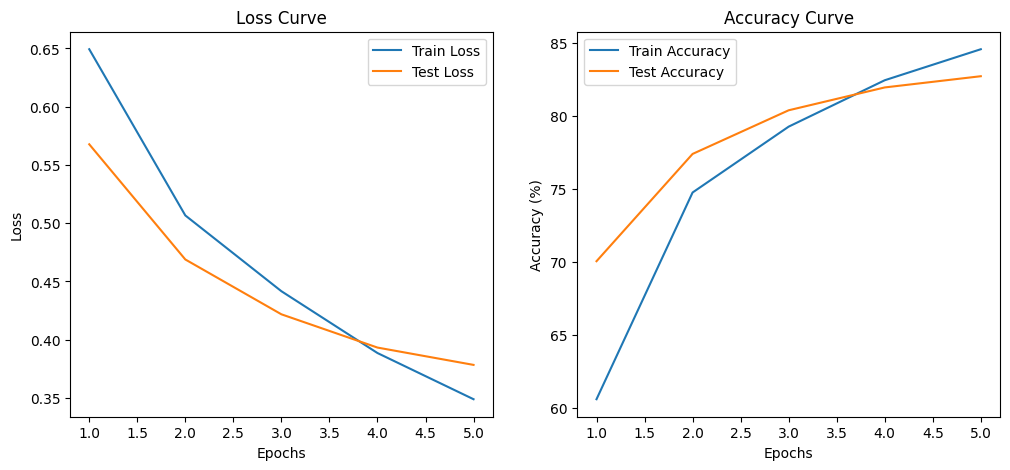

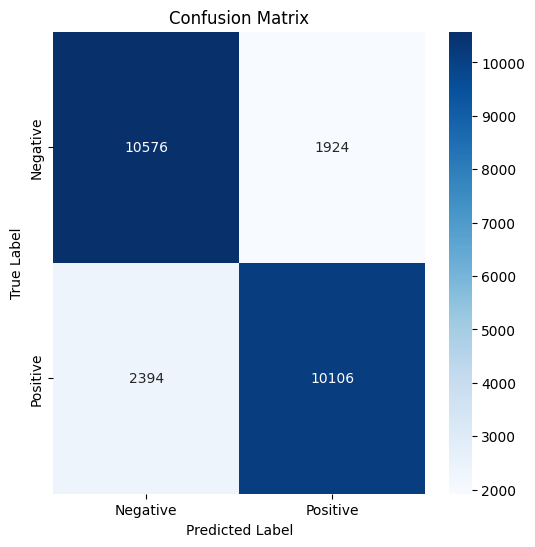

 Test Accuracy: 82.73%
 Training Time: 112.20 seconds
Num of Parameters: 4302594


In [ ]:
result = []
model = TransformerClassifier(
    vocab_size, embed_dim, num_heads, ff_dim,
    num_layers, num_classes, max_seq_length, dropout).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)

torch.cuda.empty_cache()
if torch.cuda.is_available():
    torch.cuda.reset_max_memory_allocated(device)
start_mem = torch.cuda.max_memory_allocated(device) if torch.cuda.is_available() else 0
start_time = time.time()

train_losses, test_losses, train_accuracies, test_accuracies = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device=device)

end_time = time.time()
total_time = end_time - start_time
end_mem = torch.cuda.max_memory_allocated(device) if torch.cuda.is_available() else 0
memory_usage = (end_mem - start_mem) / (1024 ** 2)

final_accuracy = test_accuracies[-1]

result.append({
    "accuracy": final_accuracy,
    "training_time": total_time,
    "memory_usage": memory_usage,
    "num_parameters": total_params,
    "accuracy_per_time": final_accuracy / total_time
})

df_result = pd.DataFrame(result)

_, _, all_labels, all_preds = evaluate_model(model, test_loader, criterion, device)
plot_learning_curve(train_losses, test_losses, train_accuracies, test_accuracies)
plot_confusion_matrix(all_labels, all_preds, class_names=["Negative", "Positive"])

print(f" Test Accuracy: {final_accuracy:.2f}%")
print(f" Training Time: {total_time:.2f} seconds")
print(f" Num of Parameters: {total_params}")